In [112]:
import pandas as pd
pd.options.mode.chained_assignment = None
import numpy as np
import random
from scipy import stats

import seaborn as sns
import matplotlib.pyplot as plt

import yfinance as yf

def normal_auc(u=0, sd=1, fill_min=0, fill_max=0,title=None):
    mn=u-(sd*4)
    mx=u+(sd*4)
    x = np.linspace(mn, mx, 100)
    y = stats.norm.pdf(x, loc=u, scale=sd)
    fig, ax = plt.subplots(figsize=(8, 5))
    p=sns.lineplot(x=x, y=y);
    if title:
        ax.set(title=title)
    if u==0 and sd==1:
        ax.set_xticks([-4, -3, -2, -1, 0, 1, 2, 3, 4])
        ax.set_xticklabels(['-4\u03C3', '-3\u03C3', '-2\u03C3', '-\u03C3', '\u03bc', '\u03C3','2\u03C3','3\u03C3', '4\u03C3'])
    #if fill:
    #get x and y values
    df_xy=pd.DataFrame(columns=['x','y'])
    df_xy.x=x
    df_xy.y=y
    if fill_min != 'min'and fill_max !='max':
        x1 = df_xy.loc[(df_xy.x>=fill_min)&(df_xy.x<=fill_max)].x
    elif fill_min=='min' and fill_max!='max':
        x1 = df_xy.loc[df_xy.x<=fill_max].x
    elif fill_min!='min' and fill_max=='max':
        x1 = df_xy.loc[df_xy.x>=fill_min].x
    y1=df_xy.iloc[x1.index].y
    # Fill the area from 0 to each point
    ax.fill_between(x1, y1=0, y2=y1, color='#022d69', alpha=0.8, zorder=0);

def conf_int_t_data(data, conf_level):
    n=len(data)
    df=n-1
    sample_std=np.std(data, ddof=1)
    sample_mean=np.mean(data)
    #step 1 - find std error of sample dist
    sem=sample_std/np.sqrt(n)
    #step 2 - find critical t-value
    alpha=1-conf_level
    q=1-(alpha/2)
    t=stats.t.ppf(q, df)
    #step 3 - find margin of error
    me=sem*t
    #step 4 - contruct interval
    ci=(sample_mean-me, sample_mean+me)
    return ci

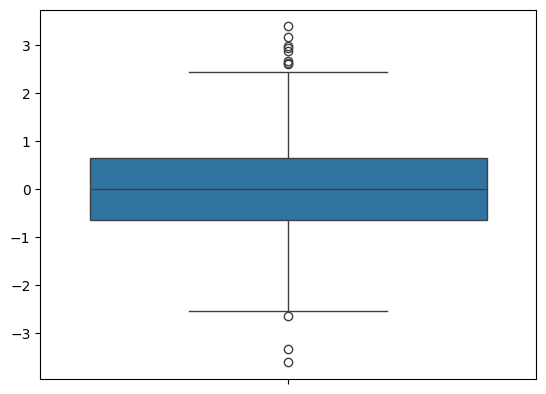

In [7]:
x=np.random.normal(loc=0, scale=1, size=1000)

sns.boxplot(y=x);

In [8]:
x=[]
for i in range(0,100):
    #100 people in the bar with net worth between 10,000 and 1,000,000
    x.append(random.randint(10000,1000000))

print('mean without bill: ', f"${np.mean(x):,.2f}")

#now add bill gates - 117,000,000,000
bill=115000000000
x.append(bill)

print('mean with bill: ', f"${np.mean(x):,.2f}")

mean without bill:  $448,526.21
mean with bill:  $1,139,057,946.74


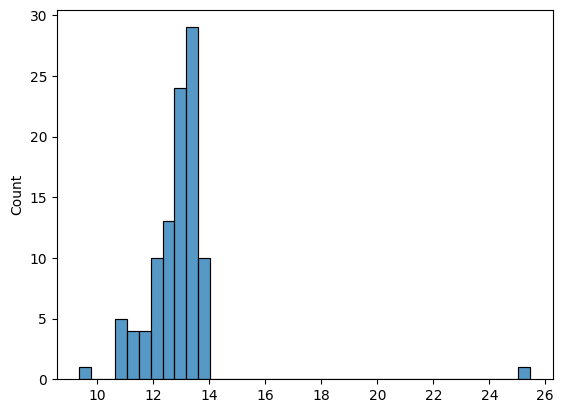

In [12]:
sns.histplot(x=[np.log(ix) for ix in x]);

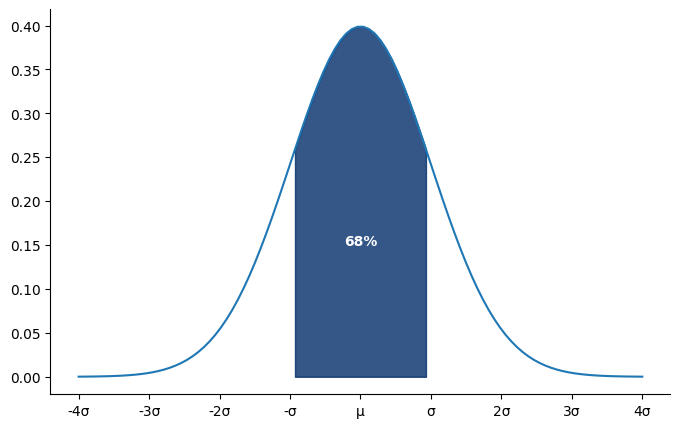

In [56]:
normal_auc(u=0, sd=1, fill_min=-1, fill_max=1)
plt.text(0,0.15, '68%', horizontalalignment='center', fontdict={'color':'white', 'weight':'bold'})
sns.despine(right=True, top=True)

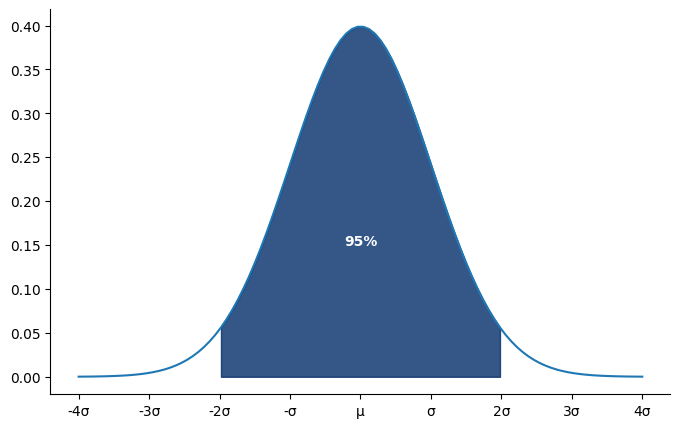

In [54]:
normal_auc(u=0, sd=1, fill_min=-2, fill_max=2)
plt.text(0,0.15, '95%', horizontalalignment='center', fontdict={'color':'white', 'weight':'bold'})
sns.despine(right=True, top=True)

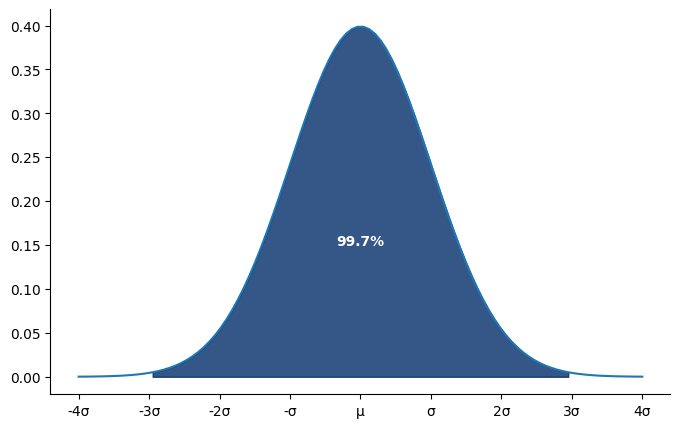

In [53]:
normal_auc(u=0, sd=1, fill_min=-3, fill_max=3)
plt.text(0,0.15, '99.7%', horizontalalignment='center', fontdict={'color':'white', 'weight':'bold'})
sns.despine(right=True, top=True)

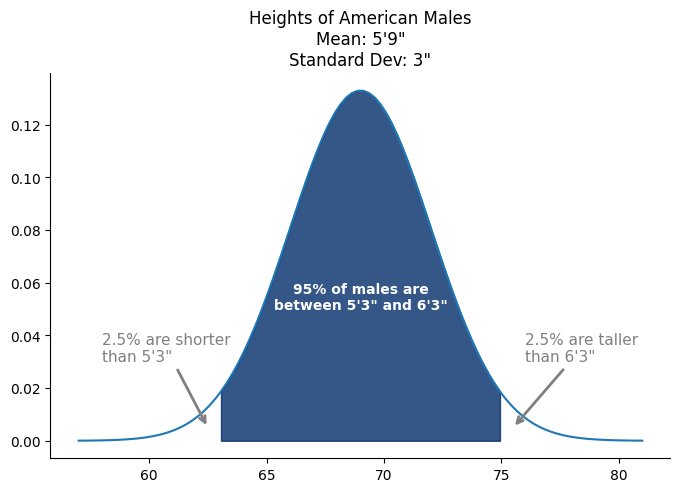

In [96]:
normal_auc(u=69, sd=3, fill_min=69-(3*2), fill_max=69+(3*2), title='Heights of American Males\nMean: 5\'9"\nStandard Dev: 3"')
plt.text(69,0.05, '95% of males are\nbetween 5\'3" and 6\'3"', horizontalalignment='center', fontdict={'color':'white', 'weight':'bold'})
plt.annotate('2.5% are taller\nthan 6\'3"', #add what we want 
            xy=(75.5, 0.005), xytext=(76, 0.03), # xy: The end point of the arrow (arrowhead position); xytext: The start point of the arrow (arrow tail position)
            arrowprops=dict(arrowstyle='->', color='grey', lw=2), #lw: linewidth in pixels
            fontsize=11, color='grey')
plt.annotate('2.5% are shorter\nthan 5\'3"', #add what we want 
            xy=(62.5, 0.005), xytext=(58, 0.03), # xy: The end point of the arrow (arrowhead position); xytext: The start point of the arrow (arrow tail position)
            arrowprops=dict(arrowstyle='->', color='grey', lw=2), #lw: linewidth in pixels
            fontsize=11, color='grey')
sns.despine(right=True, top=True)

# Standard Error

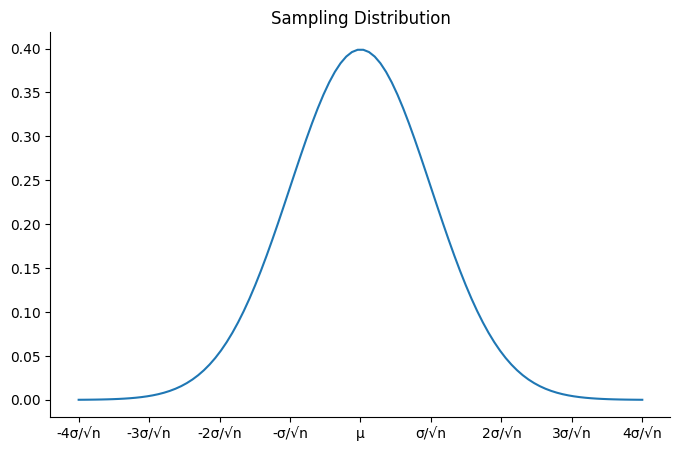

In [153]:
mn=-4
mx=4
x = np.linspace(mn, mx, 100)
y = stats.norm.pdf(x, loc=0, scale=1)
fig, ax = plt.subplots(figsize=(8, 5))
p=sns.lineplot(x=x, y=y).set_title('Sampling Distribution');
ax.set_xticks([-4, -3, -2, -1, 0, 1, 2, 3, 4])
ax.set_xticklabels(['-4\u03C3/\N{SQUARE ROOT}n', '-3\u03C3/\N{SQUARE ROOT}n', '-2\u03C3/\N{SQUARE ROOT}n', '-\u03C3/\N{SQUARE ROOT}n', 
                    '\u03bc', '\u03C3/\N{SQUARE ROOT}n','2\u03C3/\N{SQUARE ROOT}n','3\u03C3/\N{SQUARE ROOT}n', '4\u03C3/\N{SQUARE ROOT}n'])
sns.despine(right=True, top=True);

# Confidence Intervals

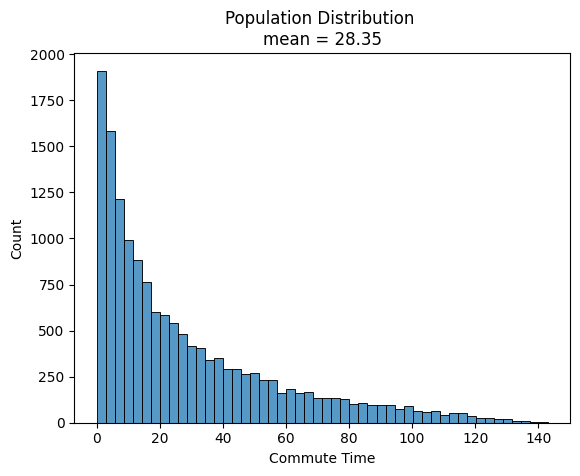

In [107]:
# Generate an array of multiple random numbers from a right-skewed distribution
n = 15000
# Right-skewed triangular distribution
data = [random.triangular(0, 12, 2)**2 for _ in range(n)] # min, max, mode
pop_mean=np.mean(data)

#population distribution
sns.histplot(x=data).set_title('Population Distribution \nmean = '+str(round(pop_mean,2)))
plt.xlabel('Commute Time');
#plt.axvline(x=pop_mean, color='crimson', linestyle='--', alpha=0.8);

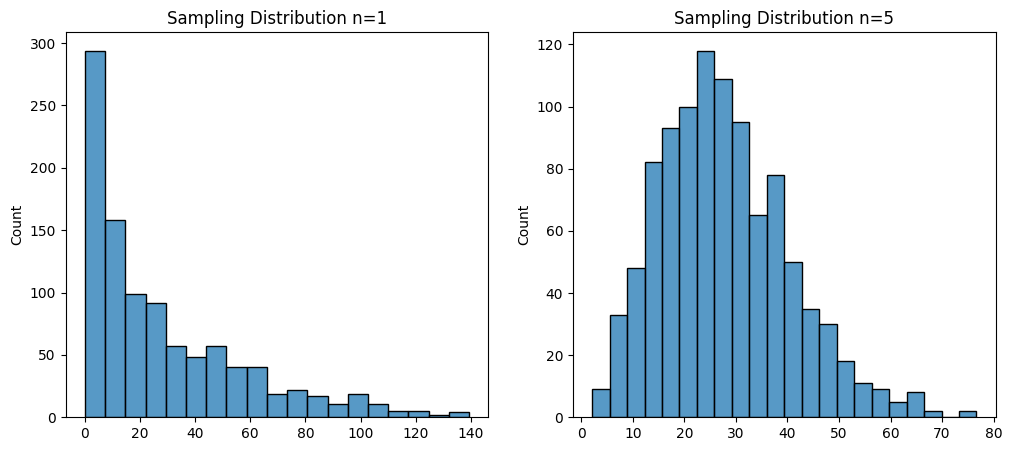

In [111]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for axi, n in enumerate([1,5]):
    d_sample={}
    for i in range(0,1000):
        sample = np.random.choice(data, size=n, replace=False)
        sample_mean=np.mean(sample)
        #sample_std=np.std(sample, ddof=1)
        #ci=conf_int_t(data=sample, conf_level=0.95)
        d_sample[i]={'sample_mean': sample_mean,
                     #'ci':ci
                    }
    x=[d_sample[i]['sample_mean'] for i in d_sample]   
    sns.histplot(x=x, ax=ax[axi]).set_title('Sampling Distribution n='+str(n));

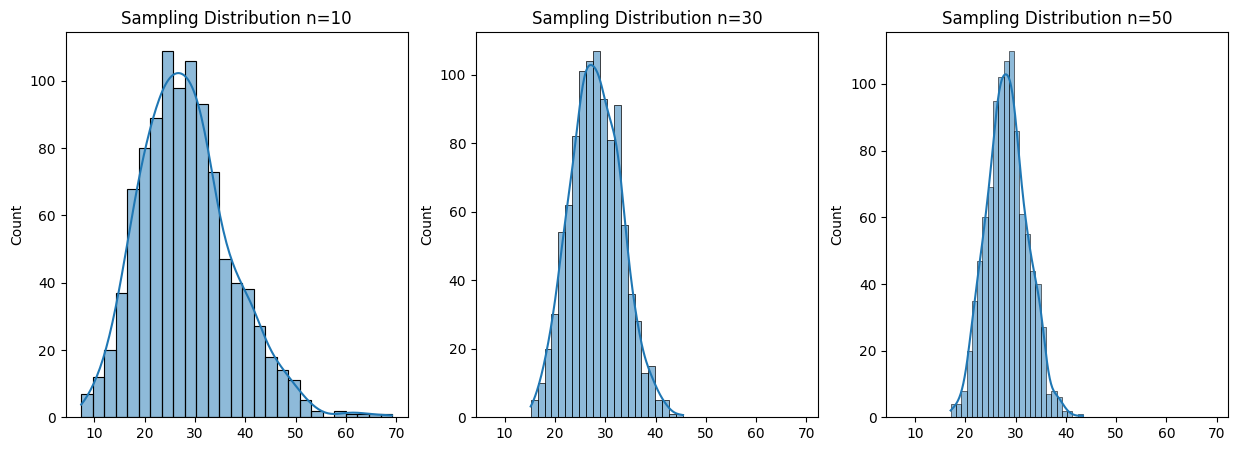

In [115]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharex=True)
for axi, n in enumerate([10, 30, 50]):
    d_sample={}
    for i in range(0,1000):
        sample = np.random.choice(data, size=n, replace=False)
        sample_mean=np.mean(sample)
        ci=conf_int_t_data(data=sample, conf_level=0.95)
        d_sample[i]={'sample_mean': sample_mean,
                     'ci':ci
                    }
    x=[d_sample[i]['sample_mean'] for i in d_sample]   
    sns.histplot(x=x, ax=ax[axi],kde=True).set_title('Sampling Distribution n='+str(n));

$$
\frac{\sigma}{\sqrt{n}}
$$

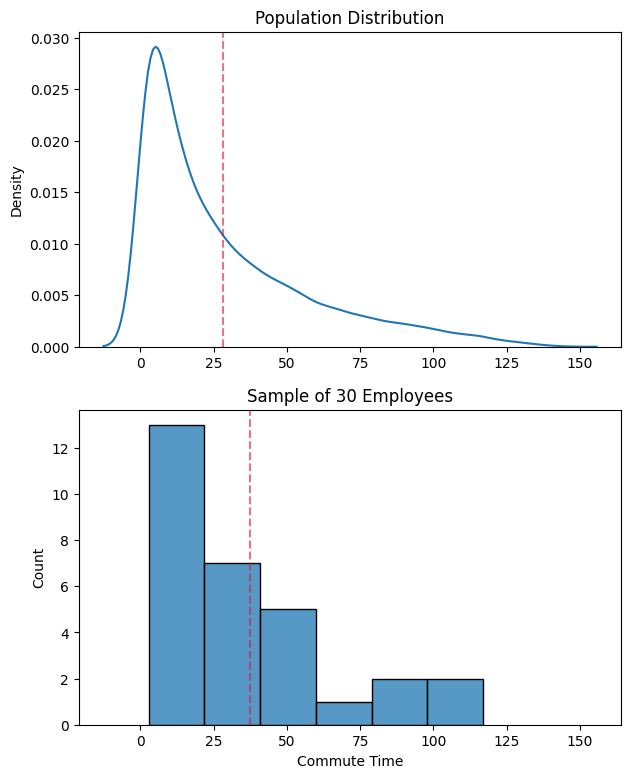

In [167]:
fig, ax = plt.subplots(2,1, figsize=(7, 9), sharex=True)

#population
sns.kdeplot(x=data, ax=ax[0]).set_title('Population Distribution')
ax[0].axvline(x=np.mean(data),linestyle='--', color='crimson', alpha=0.6);
ax[0].xaxis.set_tick_params(which='both', labelbottom=True)
plt.xlabel('Commute Time');


#sample
sample = np.random.choice(data, size=30, replace=False)
sns.histplot(x=sample, ax=ax[1]).set_title('Sample of 30 Employees')
ax[1].axvline(x=np.mean(sample),linestyle='--', color='crimson', alpha=0.6);

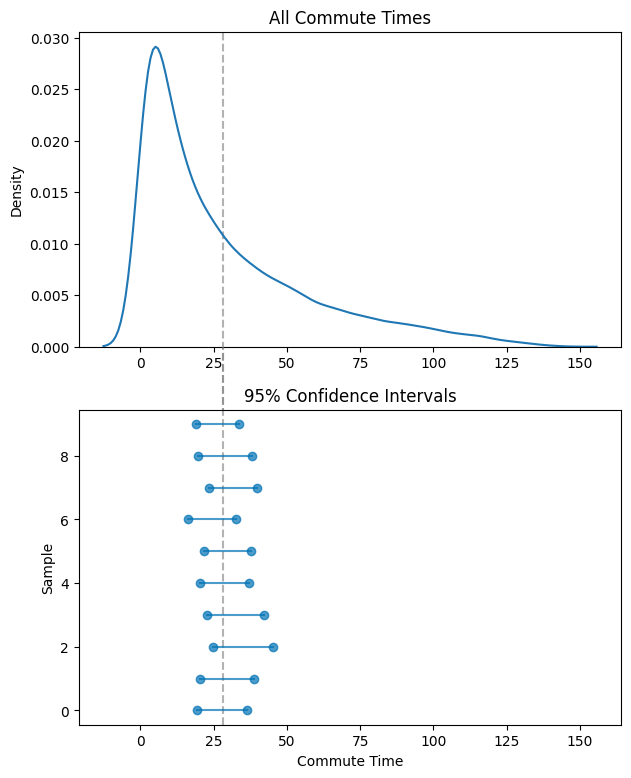

In [140]:
fig, ax = plt.subplots(2,1, figsize=(7, 9), sharex=True)

#popultaion
sns.kdeplot(x=data, ax=ax[0]).set_title('All Commute Times');
ax[0].xaxis.set_tick_params(which='both', labelbottom=True)
#confidence intervals from sample
#ax[1].axvline(x=pop_mean, color='grey', linestyle='--')
ax[0].axvline(x=pop_mean, ymin=-1.2,ymax=1, zorder=0, clip_on=False, linestyle='--', color='grey', alpha=0.6)
ax[1].axvline(x=pop_mean, ymin=0,ymax=1.2, zorder=0, clip_on=False, linestyle='--', color='grey', alpha=0.6)
for i in range(0,10):
    ci=d_sample[i]['ci']
    ax[1].plot([ci[0], ci[1]], [i, i], '-o', color='#0072b5ff', alpha=0.7)
ax[1].set(ylabel='Sample', xlabel='Commute Time', title='95% Confidence Intervals');